# Sähkön tuotannon ja kulutuksen tasapaino Suomessa

## Datan lataus ja esikäsittely

Tämän skriptin tarkoituksena on ladata automaattisesti sähköjärjestelmän aikasarja-aineistoja Fingridin avoimen datan rajapinnasta ja tallentaa ne paikallisiksi CSV-tiedostoiksi analyysia varten.

In [9]:
import requests
import pandas as pd
import time
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [3]:
# Lataa muuttujat .env tiedostosta
load_dotenv()

# Lataa API avaimen turvallisesti
API_KEY = os.getenv("API_KEY")

In [28]:
 

# Määritää aikarajan
START_TIME = "2022-01-01T00:00:00Z"
END_TIME   = "2025-12-31T00:00:00Z" 

# reaaliaikaisiin mittauksiin perustuvat datasetit (Päivittyy 3 minuutin välein)
DATASETS = {
    "Kokonaiskulutus": 193,      # Reaalinenaikainen kokonaiskulutus
  "Kokonaistuotanto": 192,       # Reaaliaikainen tuotanto
    "Tuulivoimatuotanto": 181,             # Reaaliaikainen tuulituotanto
    "Ydinvoima": 188,          # Reaaliaikainen ydinvoima
    "nettotuontiJaVienti": 194        # Reaaliaikainen tuonti/vienti
}

# Funktio datasettien lataamiseen ja .csv tiedostojen luontiin
def download_fingrid_data(dataset_name, dataset_id, api_key):
    print(f"--- Ladataan {dataset_name} (ID: {dataset_id}) ---")
    
    url = f"https://data.fingrid.fi/api/datasets/{dataset_id}/data"
    headers = {"x-api-key": api_key}
    
    all_rows = []
    page = 1
    
    while True:
        params = {
            "startTime": START_TIME,
            "endTime": END_TIME,
            "format": "json",
            "pageSize": 20000,
            "page": page
        }
        
        # Tee pyyntö
        try:
            response = requests.get(url, headers=headers, params=params)
        except Exception as e:
            print(f"   ! Yhteysvirhe: {e}")
            break
        
        # Käsittele liian monta pyyntö virhe 429
        if response.status_code == 429:
            print(f"   ! Rajoitus saavutettu sivulla {page}. Odotetaan 60s...")
            time.sleep(60)
            continue
        
        # Käsittele muut virheet
        if response.status_code != 200:
            print(f"   ! Virhe sivulla {page}: {response.status_code}")
            break
            
        # Käsittele data
        data = response.json()
        current_rows = data.get('data', [])
        
        if len(current_rows) == 0:
            print("   > Lataus valmis.")
            break
            
        all_rows.extend(current_rows)
        
        # Tilannepäivitys
        if page % 5 == 0:
            print(f"   Sivu {page}: Kerätty {len(all_rows)} riviä...")
            
        page += 1
        time.sleep(1.0) # Tauko

    # Luo .csv tiedoston jokaiselle eri datasetille, jotta meidän tarvitsee hakea data vain kerran
    if len(all_rows) > 0:
        df = pd.DataFrame(all_rows)
        
        # Muutetaan päivämääräntpythonin datetime muotoon, jotta python ymmärtää nämä päivämääriksi
        if 'startTime' in df.columns:
            df['startTime'] = pd.to_datetime(df['startTime'])
            df = df.set_index('startTime').sort_index()
        
        # Talenna csv
        filename = f"fingrid_{dataset_name}.csv"
        df.to_csv(filename)
        print(f"   [ONNISTUI] Tallennettu {filename} jossa {len(df)} riviä.\n")
    else:
        print("   EPÄONNISTUI dataa ei löytynyt.\n")

# Funktion ajaminen
print(f"Aoitetaan datan lataaminen\n")

for name, id_number in DATASETS.items():
    download_fingrid_data(name, id_number, API_KEY)

print("Kaikki data ladattu")

Aoitetaan datan lataaminen

--- Ladataan Kokonaiskulutus (ID: 193) ---
   Sivu 5: Kerätty 100000 riviä...
   Sivu 10: Kerätty 200000 riviä...
   Sivu 15: Kerätty 300000 riviä...
   Sivu 20: Kerätty 400000 riviä...
   Sivu 25: Kerätty 500000 riviä...
   Sivu 30: Kerätty 600000 riviä...
   Sivu 35: Kerätty 700000 riviä...
   > Lataus valmis.
   [ONNISTUI] Tallennettu fingrid_Kokonaiskulutus.csv jossa 736767 riviä.

--- Ladataan Kokonaistuotanto (ID: 192) ---
   Sivu 5: Kerätty 100000 riviä...
   Sivu 10: Kerätty 200000 riviä...
   Sivu 15: Kerätty 300000 riviä...
   Sivu 20: Kerätty 400000 riviä...
   Sivu 25: Kerätty 500000 riviä...
   Sivu 30: Kerätty 600000 riviä...
   Sivu 35: Kerätty 700000 riviä...
   > Lataus valmis.
   [ONNISTUI] Tallennettu fingrid_Kokonaistuotanto.csv jossa 736772 riviä.

--- Ladataan Tuulivoimatuotanto (ID: 181) ---
   Sivu 5: Kerätty 100000 riviä...
   Sivu 10: Kerätty 200000 riviä...
   Sivu 15: Kerätty 300000 riviä...
   Sivu 20: Kerätty 400000 riviä...
   

## Datan yhdistäminen ja perusvisualisointi
Tässä vaiheessa aiemmin ladatut erilliset CSV-tiedostot tuodaan takaisin Python-ympäristöön analysoitavaksi. Tavoitteena on luoda yhtenäinen tietokanta ja varmistaa datan laatu visualisoinnin avulla.

#### **Datan lukeminen ja indeksointi**
       
* Koodi käyttää pd.read_csv-funktiota, jossa määritellään parse_dates=True. Tämä on tärkeää, jotta merkkijonomuotoiset aikaleimat muuttuvat Pythonin DateTime-objekteiksi. Aineisto luetaan Pandasin avulla CSV-tiedostoista. Aikaleimat muunnetaan automaattisesti päivämäärämuotoon, jotta eri tietolähteet voidaan kohdistaa toisiinsa ajallisesti.
    
* Aikaleima asetetaan taulukon indeksiksi, mikä mahdollistaa erilaisten aineistojen tarkan kohdistamisen toisiinsa, vaikka niissä olisi pieniä aikajaksollisia eroja.
* Aikaleimat myös muutetaan suomen muotoon, jotta aamun ja illan kulutuspiikit sekä Suomen kesä- ja talviajan väliset siirtymät otetaan huomioon.

#### **Yhdistäminen (pd.concat)**
   
* Erilliset tietojoukot (kulutus ja tuotanto) liitetään yhteen sivusuunnassa (akseli 1).
* Tyhjiä (Nan) arvoja sisältävät rivit poistetaan DataFramesta, jotta ennustukset ja visualisoinnit ovat mahdollisimman tarkkoja

* Pandas huolehtii automaattisesti siitä, että kulutuksen ja tuotannon arvot kohdistuvat täsmälleen samoille sekunneille tai minuuteille.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def lue_fingrid_csv(tiedosto):
    df = pd.read_csv(
        tiedosto,
        index_col='startTime',
        parse_dates=True
    )

    # Jos aikaleima on tz-naive → lokalisoidaan UTC:ksi
    if df.index.tz is None:
        df.index = df.index.tz_localize('UTC')

    # Muunnetaan Suomen aikaan
    df.index = df.index.tz_convert('Europe/Helsinki')

    return df[['value']]


kulutus = lue_fingrid_csv('fingrid_Kokonaiskulutus.csv')
tuotanto = lue_fingrid_csv('fingrid_Kokonaistuotanto.csv')

df = pd.concat([kulutus, tuotanto], axis=1)
df.columns = ['Kulutus (MW)', 'Tuotanto (MW)']






#### **Tyhjien arvojen käsittely**
Tarkistetaan puuttuvien arvojen lukumäärä sarakkeissa ja sen jälkeen puuttuvien arvojen prosentuaalinen osuus kaikista arvoista.

Tämän jälkeen muodostetaan erillinen Dataframe puuttuvista arvoista, jotta niiden visualisointi on helpompaa. Huomaa, että kaikki on saman päivän aikana ja kulutuksen mittauksessa on 15 minuutin tauko 14:58:00 - 15:13:00 välillä:


In [27]:
# Laskee puuttuvat arvot jokaisesta sarakkeesta
print(df.isnull().sum())

# Laskee puuttuvien arvojen prosenttiosuuden
print(df.isnull().mean() * 100)

Kulutus (MW)     6
Tuotanto (MW)    1
dtype: int64
Kulutus (MW)     0.000814
Tuotanto (MW)    0.000136
dtype: float64


In [28]:
missing_data = df[df['Kulutus (MW)'].isna() | df['Tuotanto (MW)'].isna()]
missing_data

,Kulutus (MW),Tuotanto (MW)
startTime,,
2023-03-08 10:52:00+02:00,11647.0,NaN
2023-03-08 14:58:00+02:00,NaN,10668.0
2023-03-08 15:01:00+02:00,NaN,10715.0
2023-03-08 15:04:00+02:00,NaN,10700.0
2023-03-08 15:07:00+02:00,NaN,10740.0
2023-03-08 15:10:00+02:00,NaN,10751.0
2023-03-08 15:13:00+02:00,NaN,10810.0


#### **Tyhjien arvon täyttäminen**

Tyhjät arvot täytetään aikapohjaisella lineaarisella interpoloinnilla:

* Jos yksi kolmen minuutin aikaväli puuttuu, se löytää keskipisteen kahden ympäröivän pisteen välillä
* Jos setistä puuttuu pidempi aikaväli3), se piirtää suoran viivan, joka yhdistää arv. Kuten tässä setissäot kello 14.55 ja 15.16 välielä.

In [30]:
# Lineaarinen interpolointi
df_clean = df.interpolate(method='time', limit_area='inside')

In [31]:
# Laskee puuttuvat arvot jokaisesta sarakkeesta
print(df_clean.isnull().sum())

# Laskee puuttuvien arvojen prosenttiosuuden
print(df_clean.isnull().mean() * 100)

Kulutus (MW)     0
Tuotanto (MW)    0
dtype: int64
Kulutus (MW)     0.0
Tuotanto (MW)    0.0
dtype: float64


#### **Muuttujien luonti (Feature Engineering**

Lisätään 'Kulutus_liukuva' ja 'Tuotanto_liukuva' sarakkeet joihin lasketaan kulutuksen ja tuotannon kuukauden keskiarvomäärät. Tämä helpottaa datan visualisointia ja trendien tarkastelua.

In [34]:
# 30 päivän liukuva keskiarvo kausivaihtelun esiin tuomiseksi
df_clean['Kulutus_liukuva'] = df_clean['Kulutus (MW)'].rolling(window='30D').mean()
df_clean['Tuotanto_liukuva'] = df_clean['Tuotanto (MW)'].rolling(window='30D').mean()

#### **Visualisointi**

Tässä vaiheessa tarkastellaan, miltä sähkön kokonaiskulutus ja -tuotanto näyttävät ajan funktiona ja mitä yleisiä piirteitä Suomen sähköjärjestelmästä voidaan havaita.
   
* Matplotlib-kirjastolla piirretään aikasarjakaavio, jossa kulutus ja tuotanto ovat päällekkäin.

* Visualisoinnin avulla voidaan havaita sähköjärjestelmän peruspiirteet:
    - Kausivaihtelu: Sähkön kulutus on selvästi korkeimmillaan talvikuukausina.
    
    - Vuorokausivaihtelu: Miten kulutus nousee aamulla ja laskee yöllä.
    
    - Vaje/Ylijäämä: Alueet, joissa kulutuskäyrä on tuotantokäyrän yläpuolella, osoittavat tuontisähkön tarpeen.

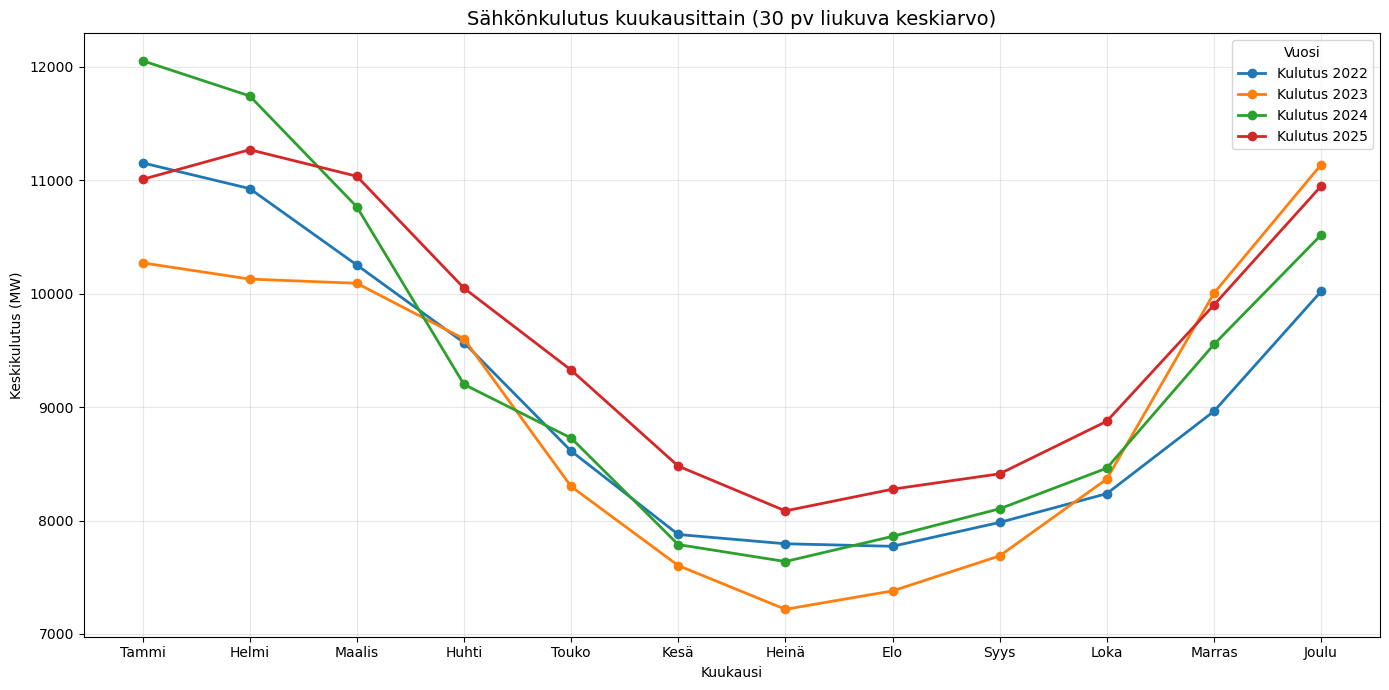

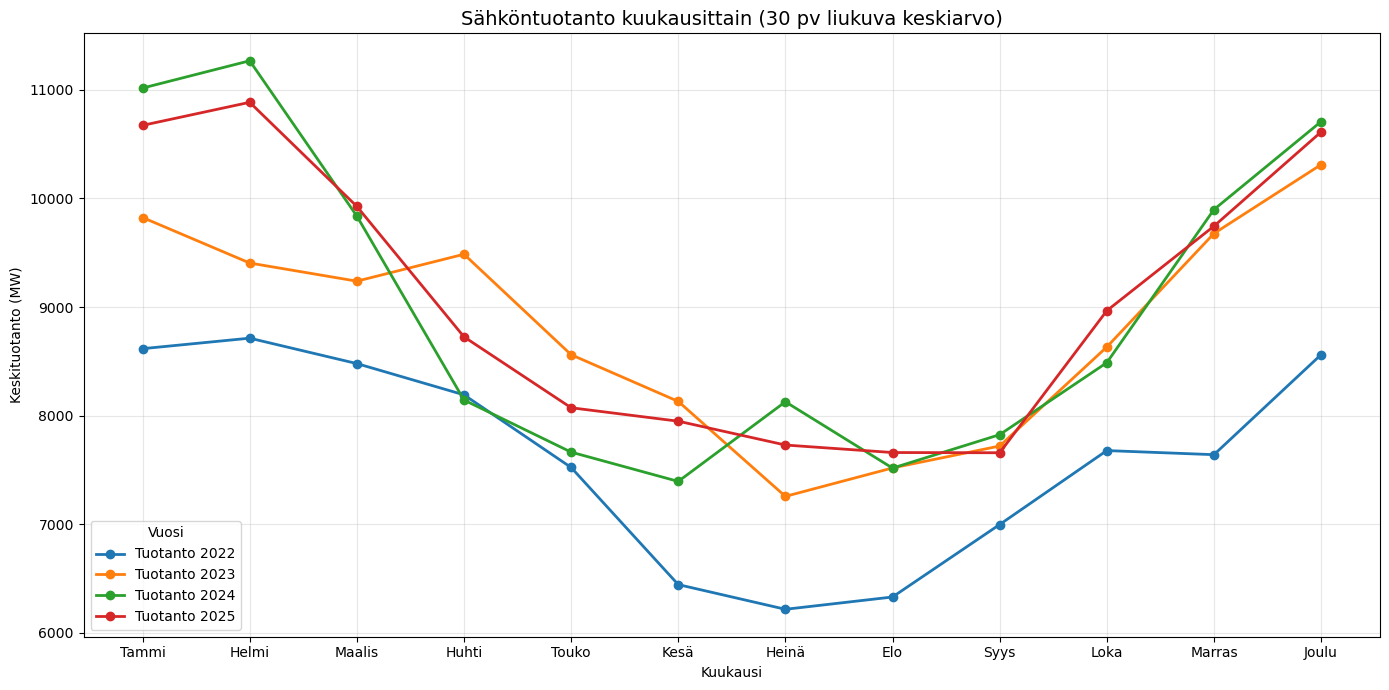

In [36]:
# Varmista järjestys
df_clean = df_clean.sort_index()

#Kulutus plot
plt.figure(figsize=(14, 7))

# Käydään vuodet läpi
for vuosi in sorted(df_clean.index.year.unique()):
    vuosi_data = df_clean[df_clean.index.year == vuosi]

    # Kuukausittainen keskiarvo liukuvasta kulutuksesta
    kuukausi_data = (
        vuosi_data['Kulutus_liukuva']
        .resample('ME')
        .mean()
    )

    plt.plot(
        kuukausi_data.index.month,
        kuukausi_data.values,
        marker='o',
        linewidth=2,
        label=f'Kulutus {vuosi}'
    )

# Kuukausien nimet x-akselille
plt.xticks(
    ticks=range(1, 13),
    labels=['Tammi','Helmi','Maalis','Huhti','Touko','Kesä',
            'Heinä','Elo','Syys','Loka','Marras','Joulu']
)

plt.title('Sähkönkulutus kuukausittain (30 pv liukuva keskiarvo)', fontsize=14)
plt.xlabel('Kuukausi')
plt.ylabel('Keskikulutus (MW)')
plt.legend(title='Vuosi')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



#Tuotanto plot

plt.figure(figsize=(14, 7))

# Käydään vuodet läpi
for vuosi in sorted(df_clean.index.year.unique()):
    vuosi_data = df_clean[df_clean.index.year == vuosi]

    # Kuukausittainen keskiarvo liukuvasta tuotannosta
    kuukausi_data = (
        vuosi_data['Tuotanto_liukuva']
        .resample('ME')
        .mean()
    )

    plt.plot(
        kuukausi_data.index.month,
        kuukausi_data.values,
        marker='o',
        linewidth=2,
        label=f'Tuotanto {vuosi}'
    )

# Kuukausien nimet x-akselille
plt.xticks(
    ticks=range(1, 13),
    labels=['Tammi','Helmi','Maalis','Huhti','Touko','Kesä',
            'Heinä','Elo','Syys','Loka','Marras','Joulu']
)

plt.title('Sähköntuotanto kuukausittain (30 pv liukuva keskiarvo)', fontsize=14)
plt.xlabel('Kuukausi')
plt.ylabel('Keskituotanto (MW)')
plt.legend(title='Vuosi')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()





### Kaavion tulkinta
Kuvasta havaitaan, että sähkön kulutus on selvästi korkeimmillaan talvikuukausina, kun taas kesällä kulutus laskee. Tuotanto seuraa osittain kulutusta, mutta ajoittain kulutus ylittää tuotannon, mikä viittaa tuontisähkön tarpeeseen.

## Nettokuorman visualisointi

Tässä osiossa tarkastellaan nettokuorman kehitystä Suomessa. Nettokuorma kuvaa sähkön kokonaiskulutuksen ja kotimaisen sähköntuotannon välistä erotusta, ja se kertoo, milloin sähköä joudutaan tuomaan Suomeen ja milloin tuotanto ylittää kulutuksen.

### Nettokuorman laskenta


* Nettokuorma lasketaan vähentämällä sähkön kokonaiskulutuksesta kotimainen sähkön tuotanto:

  Nettokuorma = Kulutus − Tuotanto

* Positiivinen nettokuorma tarkoittaa tilannetta, jossa kulutus ylittää tuotannon ja sähköä joudutaan tuomaan ulkomailta. Negatiivinen nettokuorma puolestaan kertoo tuotannon ylittävän kulutuksen, jolloin sähköä voidaan viedä.

* Aineistoon lisätään myös 30 päivän liukuva keskiarvo, jonka avulla lyhytaikainen vaihtelu tasoittuu ja pidemmän aikavälin trendit tulevat selkeämmin esiin. Tämä helpottaa erityisesti kausivaihteluiden tarkastelua.

In [41]:
df_clean['Nettokuorma'] = df_clean['Kulutus (MW)'] - df_clean['Tuotanto (MW)']
df_clean['Nettokuorma_liukuva'] = df_clean['Nettokuorma'].rolling(window='30D').mean()

### Nettokuorman vertailu vuosittain

Visualisoinnissa nettokuorman kehitystä tarkastellaan vuosittain (tammi–joulu) siten, että eri vuosien käyrät on piirretty samaan kuvaan. Näin voidaan vertailla, miten sähkötase on kehittynyt eri vuosina ja miten esimerkiksi talvi- ja kesäkaudet eroavat toisistaan.

Kuvassa:

* Vaakasuora nollaviiva toimii rajana tuonti- ja vientitilanteiden välillä.

* Nollaviivan yläpuolella nettokuorma on positiivinen, mikä viittaa tuontisähkön tarpeeseen.

* Nollaviivan alapuolella nettokuorma on negatiivinen, mikä viittaa sähkön vientimahdollisuuteen.

* Taustavärityksellä havainnollistetaan visuaalisesti tuonti- ja vientialueita.


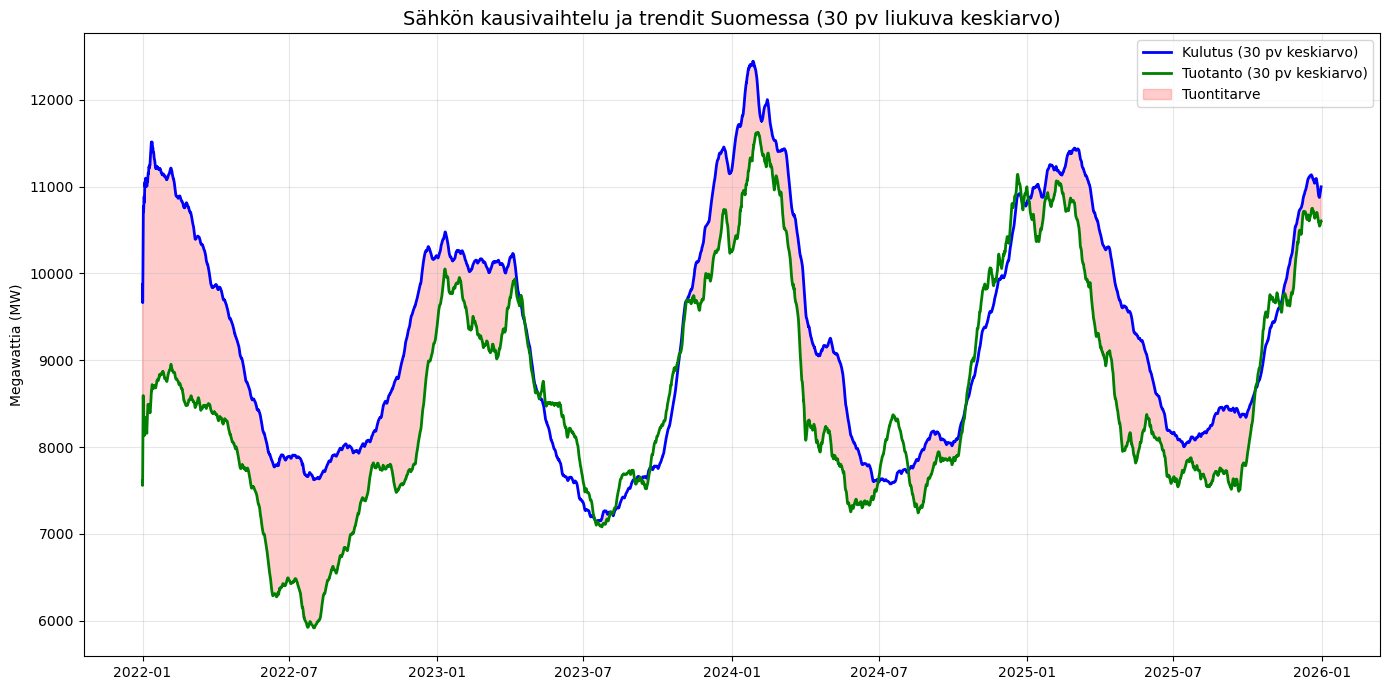

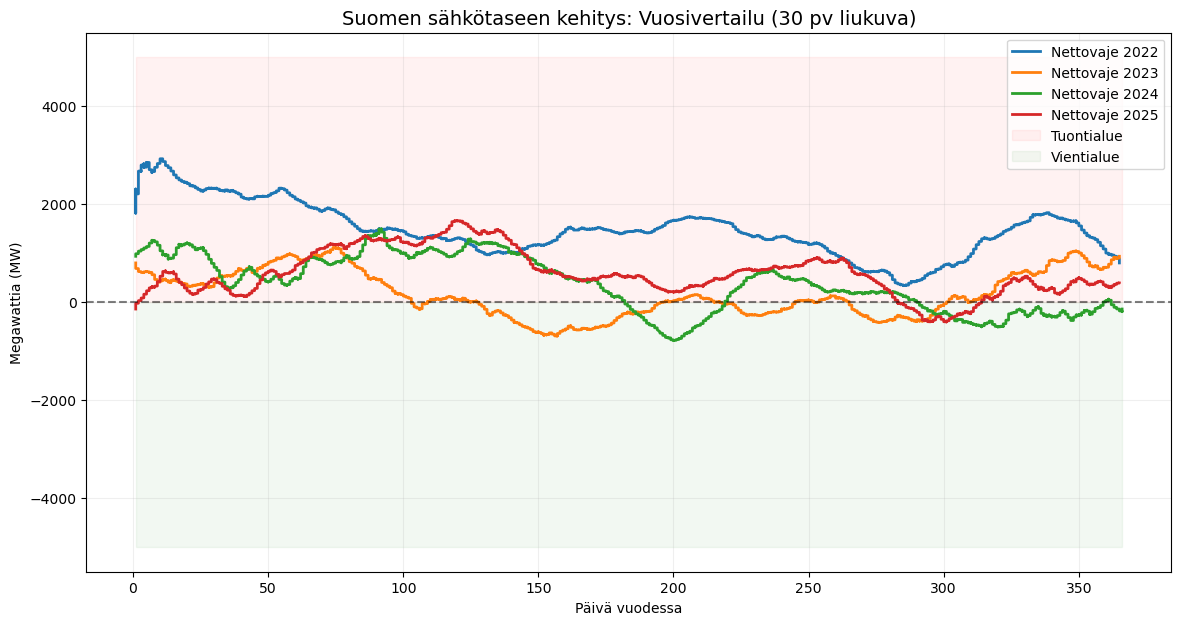

In [43]:
plt.figure(figsize=(14, 7))

# Piirrä alkuperäinen data haalistettuna
# plt.plot(df_clean.index, df_clean['Kulutus (MW)'], color='blue', alpha=0.1, label='_nolegend_')
# plt.plot(df_clean.index, df_clean['Tuotanto (MW)'], color='green', alpha=0.1, label='_nolegend_')

# Piirrä 30 päivän keskiarvot
plt.plot(df_clean.index, df_clean['Kulutus_liukuva'], color='blue', linewidth=2, label='Kulutus (30 pv keskiarvo)')
plt.plot(df_clean.index, df_clean['Tuotanto_liukuva'], color='green', linewidth=2, label='Tuotanto (30 pv keskiarvo)')

# Täytä alue missä kulutus > tuotanto
plt.fill_between(df_clean.index, df_clean['Kulutus_liukuva'], df_clean['Tuotanto_liukuva'],
                 where=(df_clean['Kulutus_liukuva'] > df_clean['Tuotanto_liukuva']),
                 color='red', alpha=0.2, label='Tuontitarve')

plt.title('Sähkön kausivaihtelu ja trendit Suomessa (30 pv liukuva keskiarvo)', fontsize=14)
plt.ylabel('Megawattia (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 7))

for vuosi in sorted(df_clean.index.year.unique()):
    vuosi_data = df_clean[df_clean.index.year == vuosi]
    # Piirretään kukin vuosi omalla värillään
    plt.plot(vuosi_data.index.dayofyear, vuosi_data['Nettokuorma_liukuva'], 
             label=f'Nettovaje {vuosi}', linewidth=2)

# Lisätään nollaviiva - sen yläpuolella ollaan tuontiriippuvaisia
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.fill_between(range(1, 367), 0, 5000, color='red', alpha=0.05, label='Tuontialue')
plt.fill_between(range(1, 367), 0, -5000, color='green', alpha=0.05, label='Vientialue')

plt.title('Suomen sähkötaseen kehitys: Vuosivertailu (30 pv liukuva)', fontsize=14)
plt.xlabel('Päivä vuodessa')
plt.ylabel('Megawattia (MW)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

#### Havainnot visualisoinnista

Nettokuorman aikasarjasta voidaan havaita useita sähköjärjestelmälle tyypillisiä piirteitä:

* Kausivaihtelu: Nettokuorma on yleensä suurimmillaan talvikuukausina, jolloin sähkön kulutus kasvaa lämmityksen vuoksi.

* Kesäkausi: Kesällä nettokuorma pienenee ja joissakin jaksoissa muuttuu negatiiviseksi, mikä viittaa tuotannon ylittävän kulutuksen.

* Vuosien väliset erot: Eri vuosien välillä esiintyy selkeitä eroja nettokuorman tasossa, mikä voi johtua muun muassa sääolosuhteista, kulutusrakenteen muutoksista ja uusiutuvan energiantuotannon vaihtelusta.

### Nettokuorman tarkempi analyysi

Vuosien välistä kehitystä tarkasteltiin 30 päivän liukuvan keskiarvon avulla pitkän aikavälin trendien esiin tuomiseksi. Jakauma- ja vaihteluanalyysiä varten aineisto aggregoitiin tuntikeskiarvoiksi, jotta nettokuorman todellinen vaihtelu säilyi boxplot-kuvaajissa.

In [47]:
# Muuttaa kolumnien arvot tunnittaiksi keskiarvoiksi
df_hourly = (
    df_clean
    .resample('1h')
    .mean()
)

# Laskee netto kuorman tunnittaisilla arvoilla
df_hourly['Nettokuorma'] = (
    df_hourly['Kulutus (MW)'] - df_hourly['Tuotanto (MW)']
)


In [72]:
df_hourly.head()

,Kulutus (MW),Tuotanto (MW),Kulutus_liukuva,Tuotanto_liukuva,Nettokuorma,Nettokuorma_liukuva,Vuosi,Kuukausi,Tunti
startTime,,,,,,,,,
2022-01-01 02:00:00+02:00,9771.784997,7564.319997,9824.449502,7566.227066,2207.465000,2258.222436,2022,1,2
2022-01-01 03:00:00+02:00,9652.679997,7659.534997,9738.772583,7585.156192,1993.145000,2153.616391,2022,1,3
2022-01-01 04:00:00+02:00,9586.569996,7860.439998,9688.569518,7655.859825,1726.129998,2032.709693,2022,1,4
2022-01-01 05:00:00+02:00,9679.704998,7911.954995,9668.259032,7724.555079,1767.750002,1943.703952,2022,1,5
2022-01-01 06:00:00+02:00,9854.754996,8112.474998,9691.664917,7785.788688,1742.279998,1905.876229,2022,1,6


### Nettokuorman jakauman, keskitason ja vaihtelun analysointi

#### Boxplot on tilastollinen kuvaaja, jonka avulla havainnollistetaan numeerisen aineiston jakaumaa, keskitasoa ja vaihtelua. Se tiivistää suuren määrän havaintoja helposti tulkittavaan muotoon

**Mediaani (keskiviiva laatikon sisällä)**

* Jakaa aineiston kahtia
* Kertoo aineiston tyypillisimmän tason
* Vähemmän herkkä ääriarvoille kuin keskiarvo

**Laatikko (alakvartiili – yläkvartiili, Q1–Q3)**

* Sisältää 50 % havainnoista
* Kuvaa aineiston tavanomaista vaihteluväliä

**Viikset**
* Ulottuvat tyypillisesti 1,5 × laatikon pituuden (IQR) sisällä oleviin havaintoihin
* Kuvaavat aineiston tavanomaista äärivaihtelua

**Poikkeavat havainnot (outlierit)**

* Pisteitä viiksien ulkopuolella

* Edustavat harvinaisia tai äärimmäisiä tilanteita

* Sähköjärjestelmässä nämä voivat vastata:

    * erittäin kylmiä talvipäiviä

    * tuotantohäiriöitä

    * poikkeuksellisia sääolosuhteita

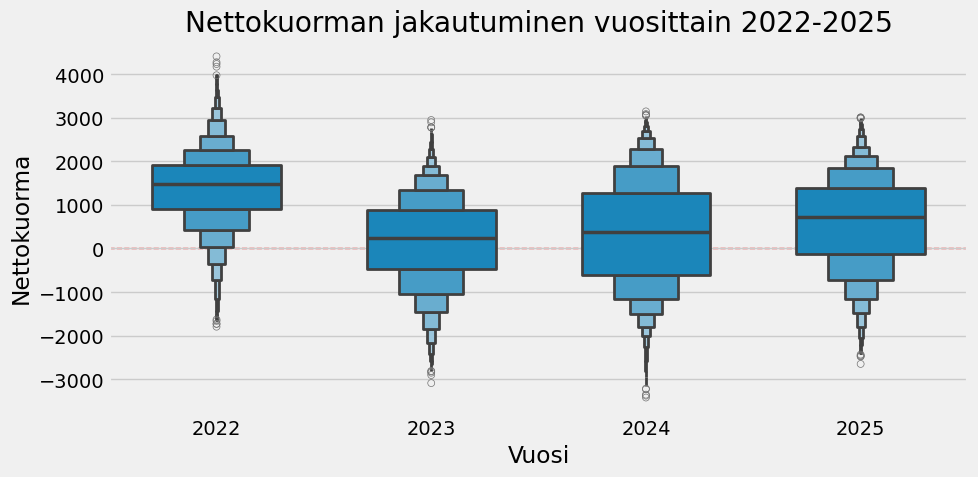

In [74]:
plt.style.use('fivethirtyeight')
import seaborn as sns

# 2. Extract time components
df_hourly['Vuosi'] = df_hourly.index.year
df_hourly['Kuukausi'] = df_hourly.index.month
df_hourly['Tunti'] = df_hourly.index.hour


# Vuosittainen nettokuorman jakautuminen
plt.figure(figsize=(10,5))
# Add zorder=0 to put the line behind the boxes
plt.axhline(0, color='red', linestyle='--', linewidth=1, zorder=0)
sns.boxenplot(x='Vuosi', y='Nettokuorma', data=df_hourly, width=0.6)
plt.title('Nettokuorman jakautuminen vuosittain 2022-2025')
plt.tight_layout()
plt.show()

#### Keskeiset havainnot

* 2022 on selvästi tuontipainotteisin vuosi:

    * korkea mediaani

    * suuri vaihteluväli

    * viittaa poikkeukselliseen kuormitustilanteeseen

* 2023 ja 2024 näyttäytyvät tasapainoisempina:

    * Mediaani lähempänä nollaa

    * Pienempi vaihtelu verrattuna vuoteen 2022

* 2025 alkaa jälleen kallistua positiivisen nettokuorman suuntaan:

    * viittaa kasvavaan tuontitarpeeseen tai kulutuksen kasvuun

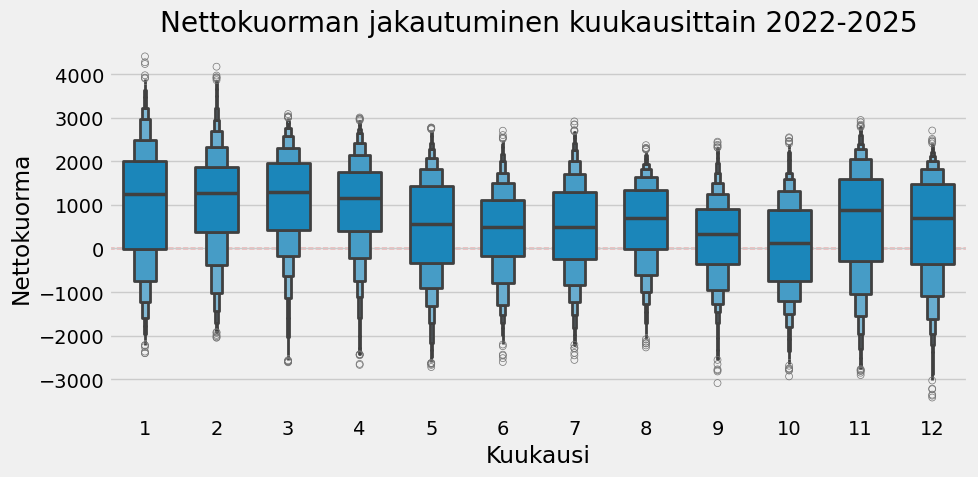

In [53]:
# Kuukausittainen nettokuorman jakautuminen
plt.figure(figsize=(10,5))
plt.axhline(0, color='red', linestyle='--', linewidth=1, zorder=0)
sns.boxenplot(x='Kuukausi', y='Nettokuorma', data=df_hourly, width=0.6)
plt.title('Nettokuorman jakautuminen kuukausittain 2022-2025')
plt.tight_layout()
plt.show()

#### Keskeiset havainnot

* Talvikuukaudet (tammi–maaliskuu, marras–joulukuu):

    * selvästi positiivinen mediaani

    * suuri hajonta ja paljon ääriarvoja

    * sähköjärjestelmä kuormittuu eniten

* Kevät (huhti–toukokuu):

    * nettokuorman mediaani laskee

    * vaihteluväli pienenee

    * järjestelmä tasapainoisempi

* Kesä (kesä–elokuu):

    * mediaani lähellä nollaa tai ajoittain negatiivinen

    * pienempi vaihtelu

    * mahdollistaa ajoittaisen viennin

* Syksy (syys–lokakuu):

    * nettokuorma alkaa kasvaa

    * vaihtelu lisääntyy kohti talvea

* Kuukausijakauma osoittaa selkeän kausiluonteisen rakenteen, ei satunnaista vaihtelua

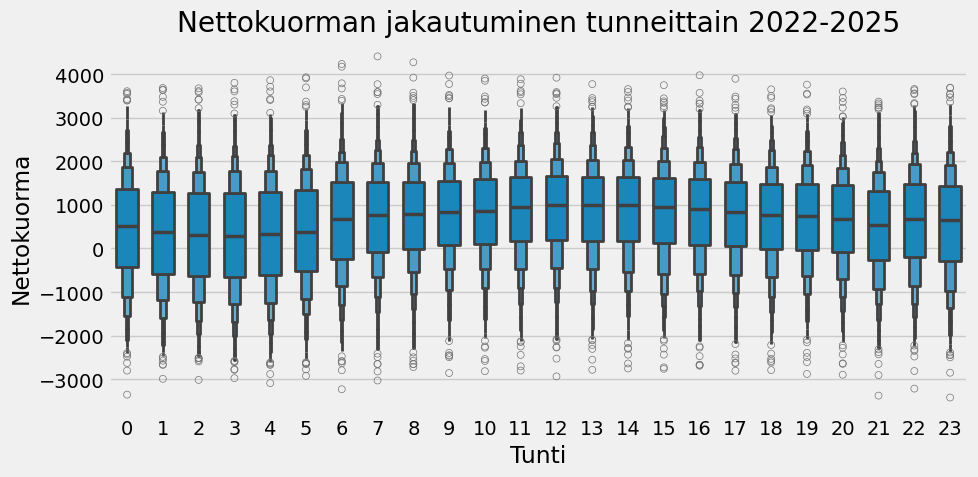

In [54]:
# Tunnittainen nettokuorman jakautuminen
plt.figure(figsize=(10,5))
sns.boxenplot(x='Tunti', y='Nettokuorma', data=df_hourly, width=0.6)
plt.title('Nettokuorman jakautuminen tunneittain 2022-2025')
plt.tight_layout()
plt.show()

#### Havainnot visualisoinnista
* Yöaika (noin 0–6):

    * matalampi mediaani

    * pienempi vaihteluväli

    * sähköjärjestelmä vakaampi

* Aamupäivä ja päivä (noin 7–16):

    * mediaani nousee

    * vaihtelu kasvaa

    * kulutuksen kasvu ja tuotannon vaihtelu korostuvat

* Ilta (noin 17–21):

    * korkea nettokuorma

    * suuri hajonta

    * huippukulutuksen vaikutus näkyy selvästi

* Kaikilla tunneilla esiintyy ääriarvoja:

    * järjestelmässä voi syntyä äkillisiä tuonti- tai ylijäämätilanteita

* Vuorokausijakauma osoittaa, että nettokuorman vaihtelu kasvaa päiväsaikaan, mikä liittyy kulutuksen ja uusiutuvan tuotannon suurempaan vaihteluun.